# MSR Development Workflow Summary

In [48]:
import rasterio
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio.plot
import numpy as np
from rasterio.plot import show
import xarray as xr
import os
from pathlib import Path

# Set up paths - adjust these to match your data location
country = "Bolivia"  # Change this to your country/region
technology = "wind"  # Change to "solarpv" or "solarcsp" as needed

# Base paths
base_path = Path(r"c:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output") / country
stage1_path = base_path / "Stage1_ScoredDatasets"
stage2_path = base_path / "Stage2_CompetitiveResourceArea"
stage4_path = base_path / "Stage4_MSR"

# Set resource type based on technology
if technology == "wind":
    resource_name = "GWA_LatAm100m"
    resource_title = "Wind Speed (m/s)"
elif technology == "solarpv":
    resource_name = "GHI"
    resource_title = "Global Horizontal Irradiance (kWh/m²/day)"
else:
    resource_name = "DNI"
    resource_title = "Direct Normal Irradiance (kWh/m²/day)"

print(f"Visualizing MSR creation process for {technology.upper()} in {country}")
print(f"Paths: {stage1_path}")

Visualizing MSR creation process for WIND in Bolivia
Paths: c:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output\Bolivia\Stage1_ScoredDatasets


## Process Overview

The Model Supply Regions (MSRs) are created through the following stages:

### 1. **Gross Resource** 
   - Raw resource maps (wind speed, solar irradiance)
   - Shows total potential across the region

### 2. **Constraint Layers** (Exclusions)
   - Protected Areas - environmental protection zones
   - Water Bodies - lakes, rivers, water surface
   - WDPA - World Database of Protected Areas
   - Slope - topographic constraints
   
   These layers are **subtracted** from the resource area

### 3. **Infrastructure Distance Scoring**
   - Distance to Transmission Grid - connectivity to high-voltage network
   - Distance to Distribution Network - local grid connectivity  
   - Distance to Roads - accessibility for construction/maintenance
   
   Areas closer to infrastructure receive **higher scores**

### 4. **Suitable Resource Area**
   - All resource areas that meet minimum thresholds
   - After applying basic constraints (e.g., no protected areas, no water bodies)

### 5. **Competitive Resource Area**
   - Best areas after scoring ALL criteria
   - Combines resource quality with infrastructure proximity
   - Typically 10-50% of suitable area depending on region

### 6. **Final MSRs**
   - Individual regions extracted from competitive resource
   - Polygonized and filtered for minimum size requirements
   - Final decision-support regions for RE deployment

## Key Insights

- Each layer is independently scored (0-1 scale)
- Scores are combined to create competitive resource map
- Larger regions are sub-divided to avoid excessively large MSRs
- Minimum area threshold ensures economically viable regions

## Cell 1: Gross Resource Potential
This cell displays the raw resource map (wind speed or solar irradiance) for the entire country/region.

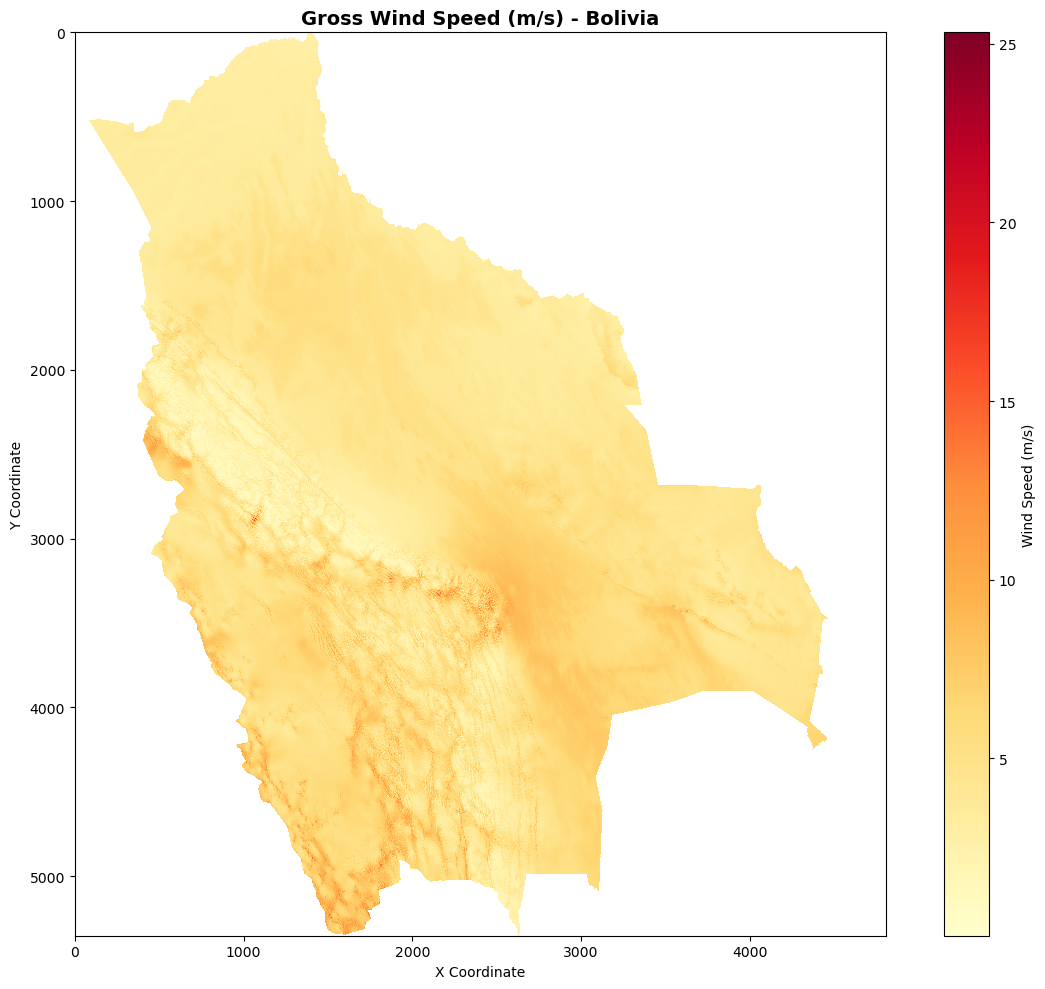

Resource data shape: (5353, 4806)
Min value: -999.00, Min positive value: 0.04, Max value: 25.32


In [ ]:
# Load and display gross resource
# Use the RAW projected data (not the Scored version which is normalized to 0-1)
input_datasets_path = base_path / "Stage1_InputDatasets"
resource_file = input_datasets_path / f"{technology}_{resource_name}_projected.tif"

if resource_file.exists():
    with rasterio.open(resource_file) as src:
        resource_data = src.read(1)
        
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Mask values <= 0 for visualization
    positive_masked = np.ma.masked_where(resource_data <= 0, resource_data)

    im = ax.imshow(positive_masked, interpolation='nearest', cmap='YlOrRd')
    
    ax.set_title(f"Gross {resource_title} - {country}", fontsize=14, fontweight='bold')
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label=resource_title)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Resource data shape: {resource_data.shape}")
    print(f"Min value: {np.nanmin(resource_data):.2f}, Min positive value: {np.nanmin(positive_masked):.2f}, Max value: {np.nanmax(resource_data):.2f}")
else:
    print(f"Resource file not found: {resource_file}")
    print(f"Looked in: {input_datasets_path}")

Weibull shape parameter (k): 2.0
Correction factor: 1.910
Original CF range: 0.000 - 1.000
Corrected CF range: 0.000 - 0.524


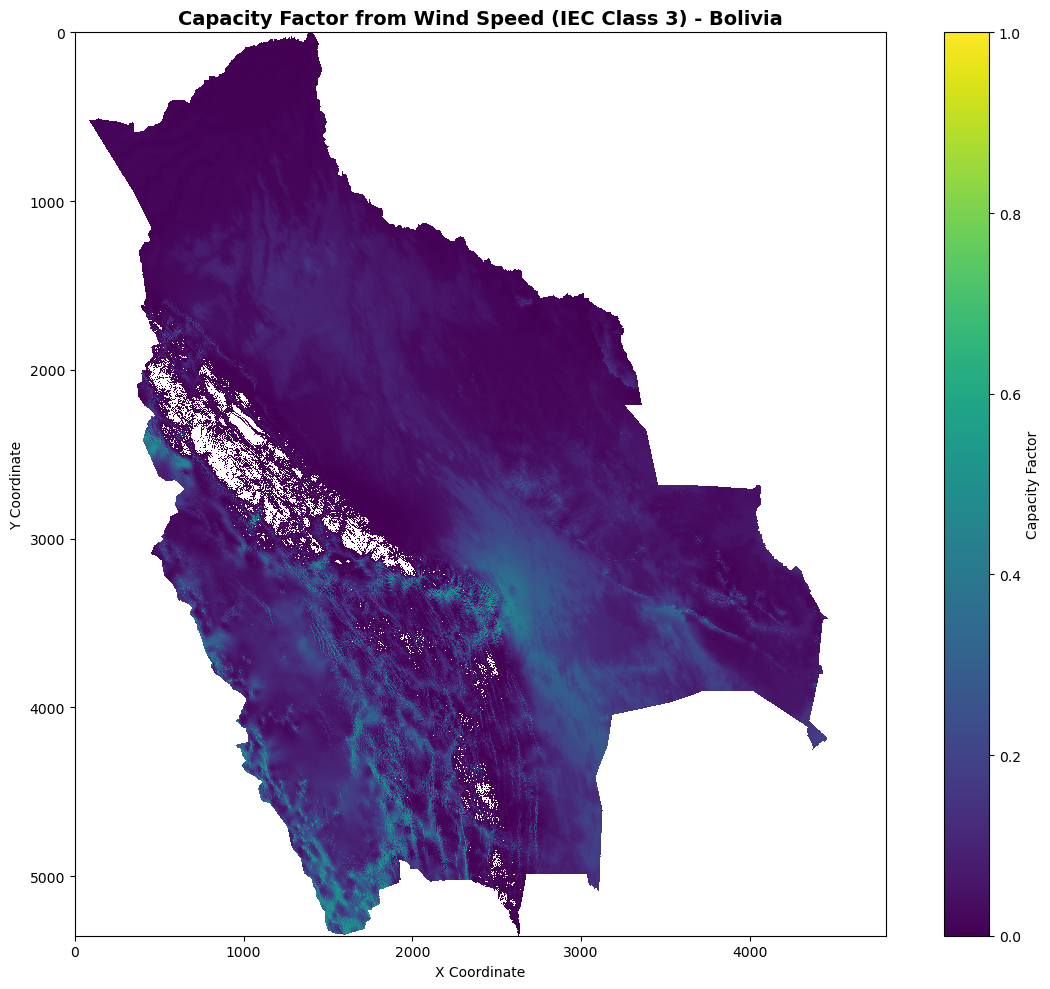

Wind Speed to Capacity Factor Conversion
Power Curve: IEC Class 3 (avg wind speed: 4.81 m/s)
Data shape: (5353, 4806)
Wind Speed range: -999.00 - 25.32 m/s
Capacity Factor range: 0.000 - 0.524


In [63]:
# Load and display gross resource converted to Capacity Factor (consistent with Profile_Generator.py)
input_datasets_path = base_path / "Stage1_InputDatasets"
resource_file = input_datasets_path / f"{technology}_{resource_name}_projected.tif"

if resource_file.exists() and technology == "wind":
    with rasterio.open(resource_file) as src:
        wind_speed_data = src.read(1)
    
    # Load IEC turbine power curves (same as Profile_Generator.py)
    power_curve_file = Path(r"c:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\2. Profile Generator\Wind speed IEC Classes.csv")
    pd_power_curves = pd.read_csv(power_curve_file, index_col=0)
    
    # Determine IEC class based on average wind speed
    avg_wind_speed = np.nanmean(wind_speed_data[wind_speed_data > 0])
    if avg_wind_speed <= 7.5:
        IEC_Class = 'IEC Class 3'
    elif avg_wind_speed < 8.5:
        IEC_Class = 'IEC Class 2'
    else:
        IEC_Class = 'IEC Class 1'
    
    # Create interpolation function for selected IEC class
    from scipy.interpolate import interp1d
    f = interp1d(pd_power_curves.index, pd_power_curves[IEC_Class], fill_value="extrapolate")
    
    # Convert wind speed to CF using power curve
    cf_data = f(wind_speed_data)
    cf_data = np.clip(cf_data, 0, 1)  # Clip to valid CF range [0, 1]
    
    ###########################
    # After calculating cf_data, apply Weibull correction
    from scipy.special import gamma as scipy_gamma

    # Weibull shape parameter (k=2 is Rayleigh, typical for on-shore wind)
    k_weibull = 2.0

    # Correction factor based on Weibull distribution
    # For cubic power curves: correction ≈ gamma(1 + 3/k) / gamma(1 + 1/k)^3
    correction_factor = scipy_gamma(1 + 3/k_weibull) / (scipy_gamma(1 + 1/k_weibull)**3)

    # Apply correction
    cf_corrected = cf_data / correction_factor

    print(f"Weibull shape parameter (k): {k_weibull}")
    print(f"Correction factor: {correction_factor:.3f}")
    print(f"Original CF range: {np.nanmin(cf_data):.3f} - {np.nanmax(cf_data):.3f}")
    print(f"Corrected CF range: {np.nanmin(cf_corrected):.3f} - {np.nanmax(cf_corrected):.3f}")
    ##########################

    # Mask values <= 0 for visualization
    cf_masked = np.ma.masked_where(cf_corrected <= 0, cf_corrected)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cf_masked,  interpolation='nearest', vmin=0, vmax=1)
    
    ax.set_title(f"Capacity Factor from Wind Speed ({IEC_Class}) - {country}", fontsize=14, fontweight='bold')
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Capacity Factor')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Wind Speed to Capacity Factor Conversion")
    print(f"Power Curve: {IEC_Class} (avg wind speed: {avg_wind_speed:.2f} m/s)")
    print(f"Data shape: {wind_speed_data.shape}")
    print(f"Wind Speed range: {np.nanmin(wind_speed_data):.2f} - {np.nanmax(wind_speed_data):.2f} m/s")
    print(f"Capacity Factor range: {np.nanmin(cf_masked):.3f} - {np.nanmax(cf_masked):.3f}")
else:
    if technology != "wind":
        print(f"Capacity Factor conversion only available for wind technology")
    else:
        print(f"Resource file not found: {resource_file}")

## Cell 2: Constraint Layers - Exclusion Areas
These cells show the major constraint/exclusion layers that are subtracted from the resource potential.

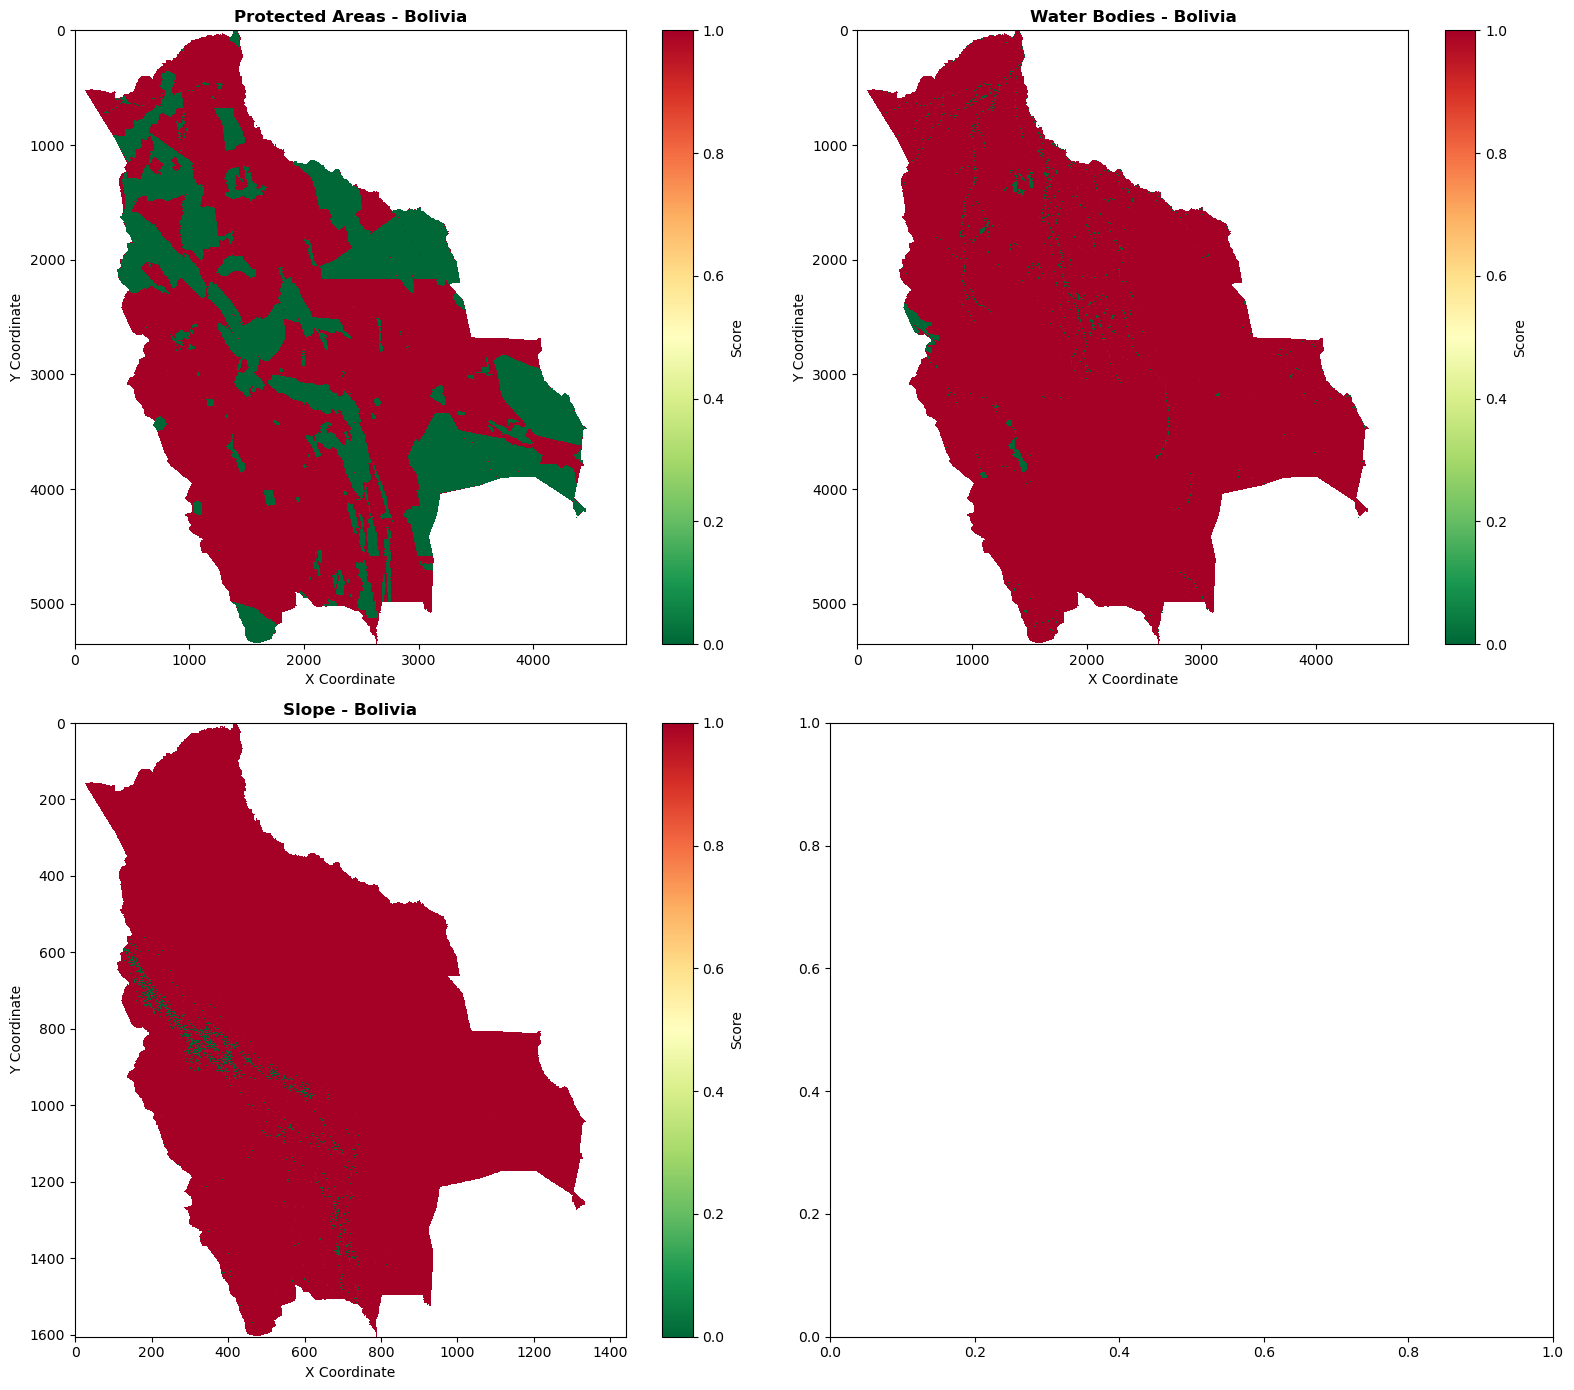

In [28]:
# Display key constraint layers
constraint_layers = {
    "Protected Areas": f"{technology}_protected_areas_fixed_RasterizedProjected_Scored.tif",
    "Water Bodies": f"{technology}_water_bodies_fixed_RasterizedProjected_Scored.tif",
    #"WDPA Protected Areas": f"{technology}_WDPA_October2023_LatAm_RasterizedProjected_Scored.tif",
    "Slope": f"{technology}_slope_projected_Scored.tif"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (layer_name, filename) in enumerate(constraint_layers.items()):
    filepath = stage1_path / filename
    
    if filepath.exists():
        with rasterio.open(filepath) as src:
            data = src.read(1)
        
        im = axes[idx].imshow(data, cmap='RdYlGn_r', interpolation='nearest')
        axes[idx].set_title(f"{layer_name} - {country}", fontsize=12, fontweight='bold')
        axes[idx].set_xlabel("X Coordinate")
        axes[idx].set_ylabel("Y Coordinate")
        plt.colorbar(im, ax=axes[idx], label='Score')
    else:
        axes[idx].text(0.5, 0.5, f"File not found:\n{filename}", 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(layer_name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell 3: Infrastructure Distance Layers
Distance to various infrastructure networks (grid, roads) impacts MSR suitability.

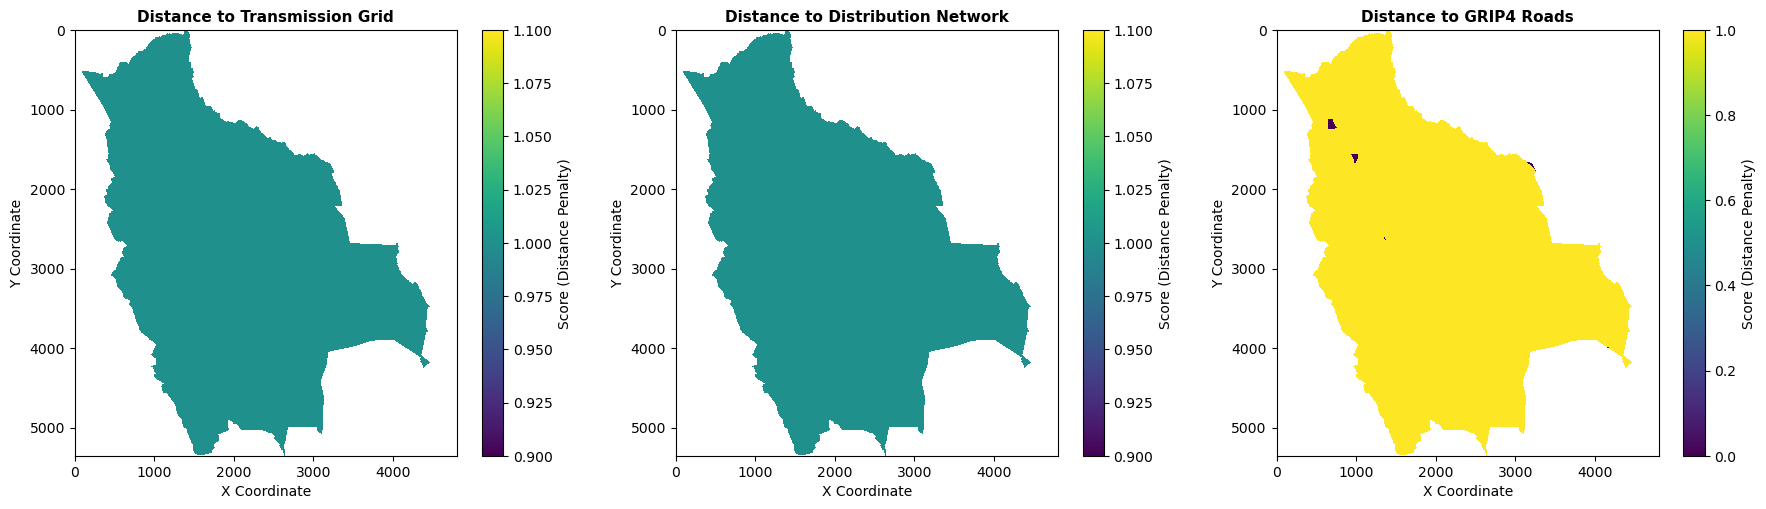

In [31]:
# Display infrastructure distance layers
distance_layers = {
    "Distance to Transmission Grid": f"{technology}_DistanceSurface_HVAC_lines_Scored.tif",
    "Distance to Distribution Network": f"{technology}_DistanceSurface_gridfinder_T_Scored.tif",
    "Distance to GRIP4 Roads": f"{technology}_DistanceSurface_GRIP4_region2_Scored.tif",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, (layer_name, filename) in enumerate(distance_layers.items()):
    filepath = stage1_path / filename
    
    if filepath.exists():
        with rasterio.open(filepath) as src:
            data = src.read(1)
        
        im = axes[idx].imshow(data, cmap='viridis', interpolation='nearest')
        axes[idx].set_title(f"{layer_name}", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("X Coordinate")
        axes[idx].set_ylabel("Y Coordinate")
        plt.colorbar(im, ax=axes[idx], label='Score (Distance Penalty)')
    else:
        axes[idx].text(0.5, 0.5, f"File not found:\n{filename}", 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

Distance to Transmission Grid: min=0.0km, max=533.0km
Distance to GRIP4 Roads: min=0.0km, max=62.8km


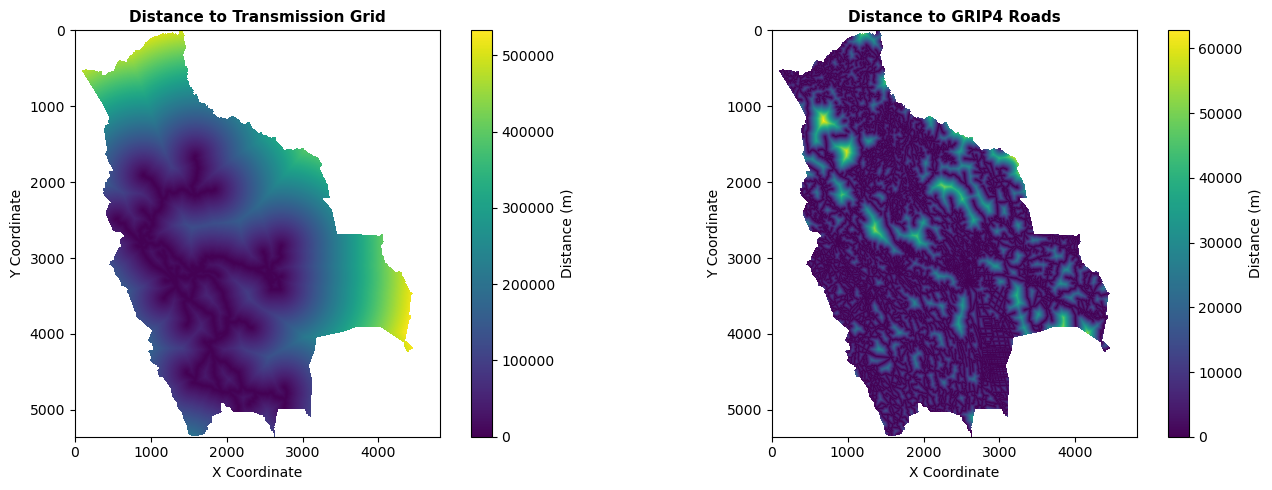

In [33]:
# Display infrastructure distance layers (raw distance values)
distance_layers = {
    "Distance to Transmission Grid": f"{technology}_DistanceSurface_HVAC_lines.tif",
    "Distance to GRIP4 Roads": f"{technology}_DistanceSurface_GRIP4_region2.tif",
}

input_datasets_path = base_path / "Stage1_InputDatasets"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

for idx, (layer_name, filename) in enumerate(distance_layers.items()):
    filepath = input_datasets_path / filename
    
    if filepath.exists():
        with rasterio.open(filepath) as src:
            data = src.read(1)
        
        # Filter out extreme/invalid values (keep reasonable distances, e.g., < 1,000 km)
        max_distance = 1e7  # 10,000 km in meters - adjust as needed
        data_filtered = np.where(data < max_distance, data, np.nan)
        
        im = axes[idx].imshow(data_filtered, cmap='viridis', interpolation='nearest')
        axes[idx].set_title(f"{layer_name}", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("X Coordinate")
        axes[idx].set_ylabel("Y Coordinate")
        cbar = plt.colorbar(im, ax=axes[idx], label='Distance (m)')
        
        # Print valid statistics only
        valid_data = data_filtered[~np.isnan(data_filtered)]
        print(f"{layer_name}: min={np.nanmin(valid_data)/1000:.1f}km, max={np.nanmax(valid_data)/1000:.1f}km")
    else:
        axes[idx].text(0.5, 0.5, f"File not found:\n{filename}", 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

## Cell 4: Suitable vs. Competitive Resource Areas
Comparison of areas meeting minimum resource thresholds (Suitable) vs. areas after scoring all criteria (Competitive).

Suitable Resource Area pixels: 15759461
Competitive Resource Area pixels: 15759461


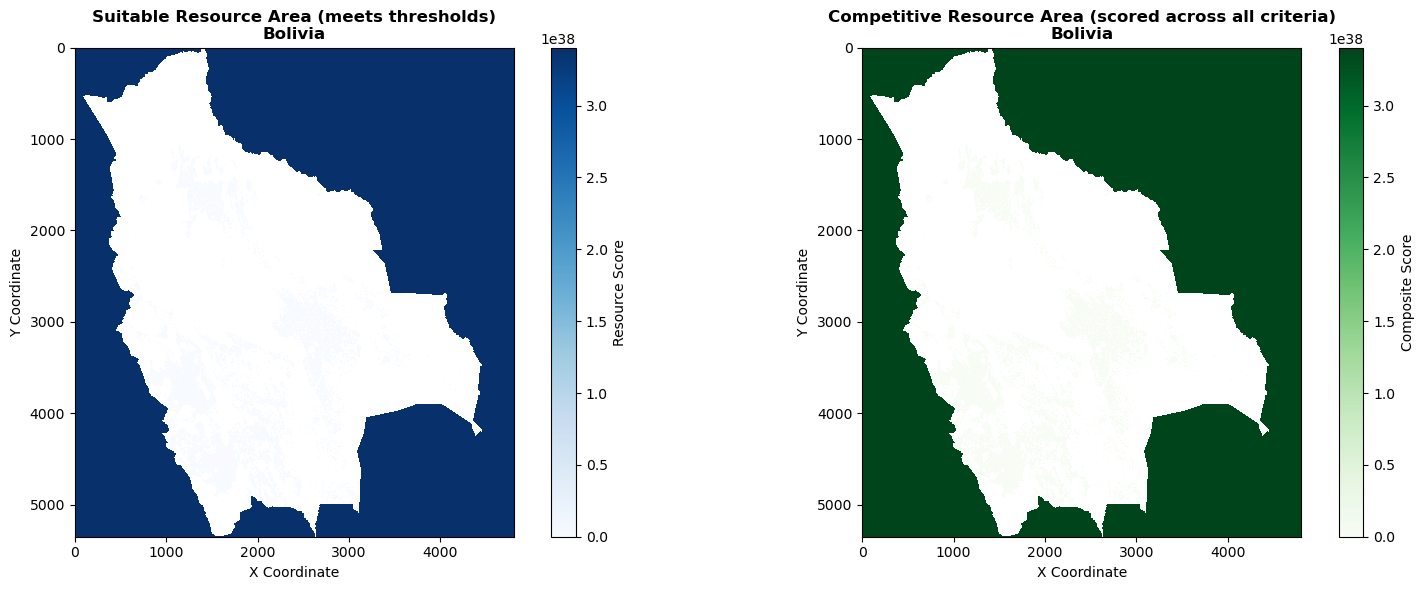


Area Reduction:
  Suitable → Competitive: 100.0% retained


In [35]:
# Load and compare Suitable vs Competitive Resource
suitable_file = stage2_path / f"{technology}_SuitableResource.tif"
competitive_file = stage2_path / f"{technology}_CompetitiveResource.tif"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Suitable Resource
if suitable_file.exists():
    with rasterio.open(suitable_file) as src:
        suitable_data = src.read(1)
    
    # Mask zero values for better visualization
    suitable_masked = np.ma.masked_where(suitable_data == 0, suitable_data)
    
    im1 = axes[0].imshow(suitable_masked, cmap='Blues', interpolation='nearest')
    axes[0].set_title(f"Suitable Resource Area (meets thresholds)\n{country}", 
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel("X Coordinate")
    axes[0].set_ylabel("Y Coordinate")
    cbar1 = plt.colorbar(im1, ax=axes[0], label='Resource Score')
    
    suitable_area = np.count_nonzero(suitable_data) 
    print(f"Suitable Resource Area pixels: {suitable_area}")
else:
    print(f"Suitable resource file not found: {suitable_file}")

# Competitive Resource
if competitive_file.exists():
    with rasterio.open(competitive_file) as src:
        competitive_data = src.read(1)
    
    # Mask zero values for better visualization
    competitive_masked = np.ma.masked_where(competitive_data == 0, competitive_data)
    
    im2 = axes[1].imshow(competitive_masked, cmap='Greens', interpolation='nearest')
    axes[1].set_title(f"Competitive Resource Area (scored across all criteria)\n{country}", 
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel("X Coordinate")
    axes[1].set_ylabel("Y Coordinate")
    cbar2 = plt.colorbar(im2, ax=axes[1], label='Composite Score')
    
    competitive_area = np.count_nonzero(competitive_data)
    print(f"Competitive Resource Area pixels: {competitive_area}")
else:
    print(f"Competitive resource file not found: {competitive_file}")

plt.tight_layout()
plt.show()

# Print statistics
if suitable_file.exists() and competitive_file.exists():
    print(f"\nArea Reduction:")
    print(f"  Suitable → Competitive: {competitive_area / suitable_area * 100:.1f}% retained")


## Cell 5: Gross Resource with Overlay of Final MSRs
The final step shows where the actual Model Supply Regions (MSRs) are created from the competitive resource areas.

Number of MSRs created: 1412
Total MSR area: 169200 km²
Average MSR area: 120 km²


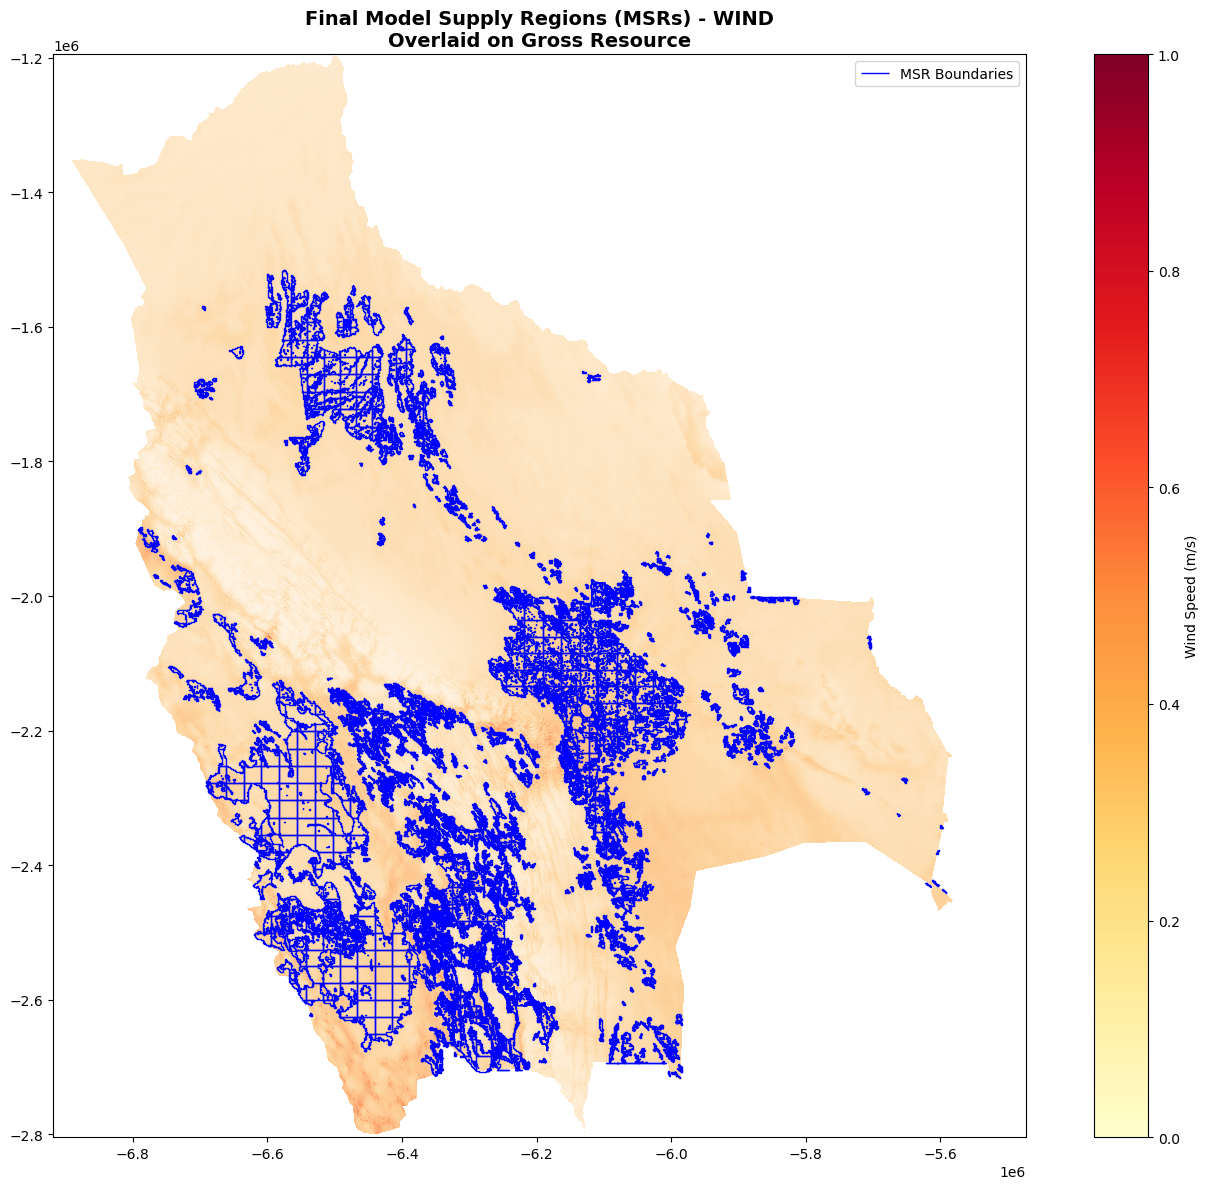

In [50]:
# Load Final MSRs shapefile
msr_shapefile = stage4_path / f"{technology}_FinalMSRs.shp"

fig, ax = plt.subplots(figsize=(14, 12))

# Plot background resource (for reference) using rasterio which handles georeferencing
if resource_file.exists():
    with rasterio.open(resource_file) as src:
        rasterio.plot.show(src, ax=ax, cmap='OrRd', alpha=1)
    cbar = plt.colorbar(im, ax=ax, label=resource_title)

# Overlay MSR boundaries
if msr_shapefile.exists():
    gdf_msr = gpd.read_file(msr_shapefile)
    
    # Ensure MSR shapefile is in same CRS as resource raster for proper alignment
    with rasterio.open(resource_file) as src:
        raster_crs = src.crs
    
    if gdf_msr.crs != raster_crs:
        gdf_msr = gdf_msr.to_crs(raster_crs)
    
    # Plot MSR boundaries
    gdf_msr.boundary.plot(ax=ax, edgecolor='blue', linewidth=1, label='MSR Boundaries')
    
    # Add some MSR attributes
    ax.set_title(f"Final Model Supply Regions (MSRs) - {technology.upper()}\nOverlaid on Gross Resource",
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    
    print(f"Number of MSRs created: {len(gdf_msr)}")
    print(f"Total MSR area: {gdf_msr.geometry.area.sum() / 1e6:.0f} km²")
    print(f"Average MSR area: {gdf_msr.geometry.area.mean() / 1e6:.0f} km²")
else:
    print(f"MSR shapefile not found: {msr_shapefile}")

plt.tight_layout()
plt.show()

## Cell 6: MSR Attributes and Statistics
Summary statistics of the final MSRs including capacity and area information.

MSR Attributes - First 10 regions:
   FID     AreakM2  CapacityMW  RoadDist  T_Dist_gf  D_Dist_gf  TD_Dist_gf  SubstnDist   Load_dst    City_name  City_Pop                                                  CtLst100kM  CtCnt100kM  PopIn100kM   Elev_mean  Elev_max  Elev_centr                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

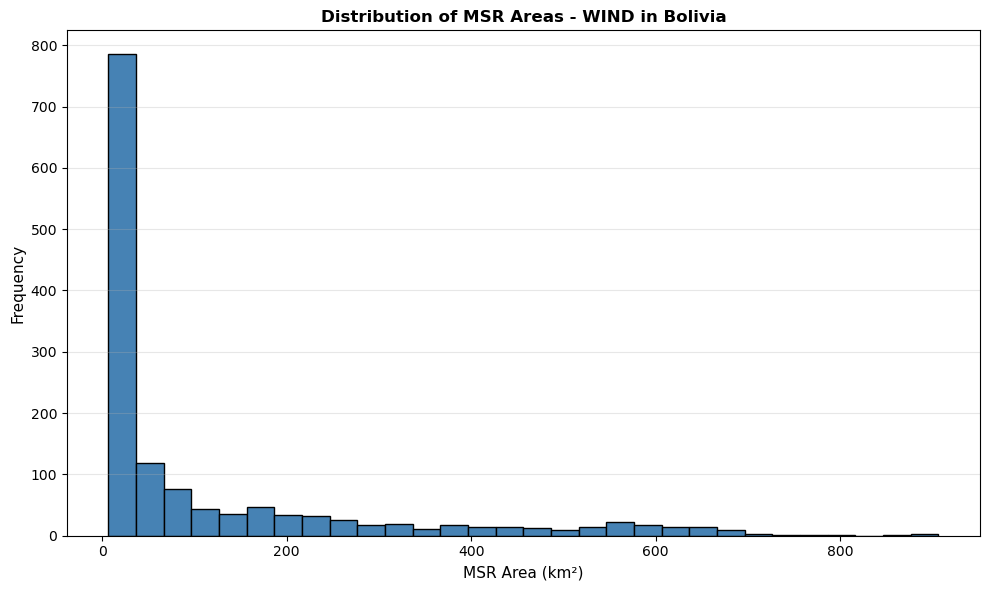

In [10]:
# Display MSR attributes
if msr_shapefile.exists():
    gdf_msr = gpd.read_file(msr_shapefile)
    
    # Show first few MSRs
    print(f"MSR Attributes - First 10 regions:")
    print(gdf_msr.head(10).to_string())
    
    # Basic statistics
    print("\n" + "="*60)
    print("MSR STATISTICS")
    print("="*60)
    print(f"Total Number of MSRs: {len(gdf_msr)}")
    print(f"\nArea Statistics (km²):")
    print(f"  Min Area: {gdf_msr.geometry.area.min() / 1e6:.2f}")
    print(f"  Max Area: {gdf_msr.geometry.area.max() / 1e6:.2f}")
    print(f"  Mean Area: {gdf_msr.geometry.area.mean() / 1e6:.2f}")
    print(f"  Median Area: {gdf_msr.geometry.area.median() / 1e6:.2f}")
    print(f"  Total Area: {gdf_msr.geometry.area.sum() / 1e6:.2f}")
    
    # Create area distribution histogram
    fig, ax = plt.subplots(figsize=(10, 6))
    areas_km2 = gdf_msr.geometry.area / 1e6
    
    ax.hist(areas_km2, bins=30, edgecolor='black', color='steelblue')
    ax.set_xlabel('MSR Area (km²)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of MSR Areas - {technology.upper()} in {country}', 
                fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No MSR shapefile available for statistics")

# Simplified representation of scoring

In [1]:
import rasterio
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio.plot
import numpy as np
from rasterio.plot import show
import xarray as xr
import os
from pathlib import Path

# Set up paths - adjust these to match your data location
country = "Bolivia"  # Change this to your country/region
technology = "wind"  # Change to "solarpv" or "solarcsp" as needed

# Base paths
base_path = Path(r"c:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output") / country

# Set resource type based on technology
if technology == "wind":
    resource_name = "GWA_LatAm100m"
    resource_title = "Wind Speed (m/s)"
elif technology == "solarpv":
    resource_name = "GHI"
    resource_title = "Global Horizontal Irradiance (kWh/m²/day)"
else:
    resource_name = "DNI"
    resource_title = "Direct Normal Irradiance (kWh/m²/day)"

In [30]:
Path_All_resources = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage1_InputDatasets/wind_GWA_LatAm100m_projected.tif")
Path_Natural_reserves = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output\Bolivia\Stage1_InputDatasets\wind_protected_areas_fixed_clipped.shp")
Path_Water_bodies = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator\Output\Bolivia\Stage1_InputDatasets\wind_water_bodies_fixed_clipped.shp")
Path_Slope_map = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage1_InputDatasets/wind_slope_projected.tif")

Path_MSR_map = Path(r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\1. MSR Creator/Output/Bolivia/Stage4_MSR/wind_FinalMSRs.shp")

## Check Datasets

In [3]:
with rasterio.open(Path_All_resources) as src:
    print(src.crs)        # coordinate reference system
    print(src.nodata)     # nodata value
    print(src.meta)       # full metadata (size, bands, dtype...)

PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
-999.0
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -999.0, 'width': 4806, 'height': 5353, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(300.60036081082995, 0.0, -6917843.318065811,
       0.0, -300.60036081082984, -119

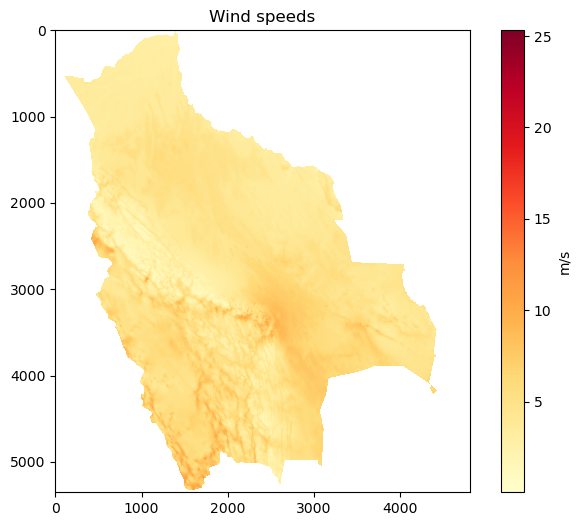

In [4]:
with rasterio.open(Path_All_resources) as src:
    data = src.read(1).astype(float)   # band 1
    data[data == src.nodata] = np.nan  # mask nodata

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="m/s")
ax.set_title("Wind speeds")
plt.show()

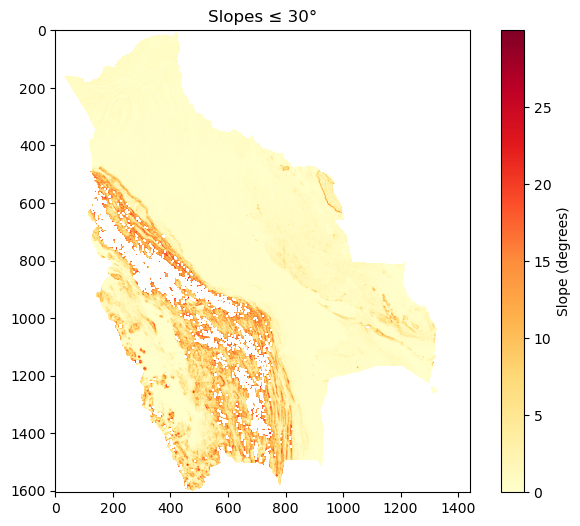

In [5]:
with rasterio.open(Path_Slope_map) as src2:
    slopes = src2.read(1).astype(float)
    nodata = src2.nodata

# Remove existing nodata first
slopes[slopes == nodata] = np.nan

# Mask out slopes above your threshold
threshold = 30  # degrees, adjust to your criteria
slopes[slopes > threshold] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(slopes, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Slope (degrees)")
ax.set_title(f"Slopes ≤ {threshold}°")
plt.show()

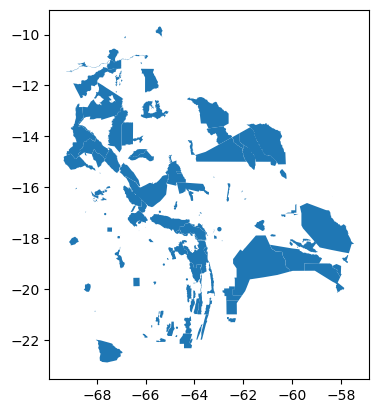

In [6]:
natural_reserves = gpd.read_file(Path_Natural_reserves)
natural_reserves.plot()
plt.show()

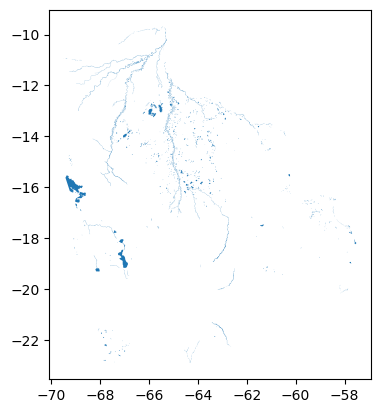

In [7]:
water_bodies = gpd.read_file(Path_Water_bodies)
water_bodies.plot()
plt.show()

## Reproject everything to match

In [8]:
print(natural_reserves.crs)

epsg:4326


In [9]:
print(water_bodies.crs)

epsg:4326


In [10]:
with rasterio.open(Path_Slope_map) as src2:
    print("Raster CRS:", src2.crs)


Raster CRS: PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [11]:
with rasterio.open(Path_All_resources) as src:
    print("Raster CRS:", src.crs)


Raster CRS: PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [12]:
natural_reserves = natural_reserves.to_crs(src.crs)
water_bodies = water_bodies.to_crs(src.crs)

## Scoring data layers

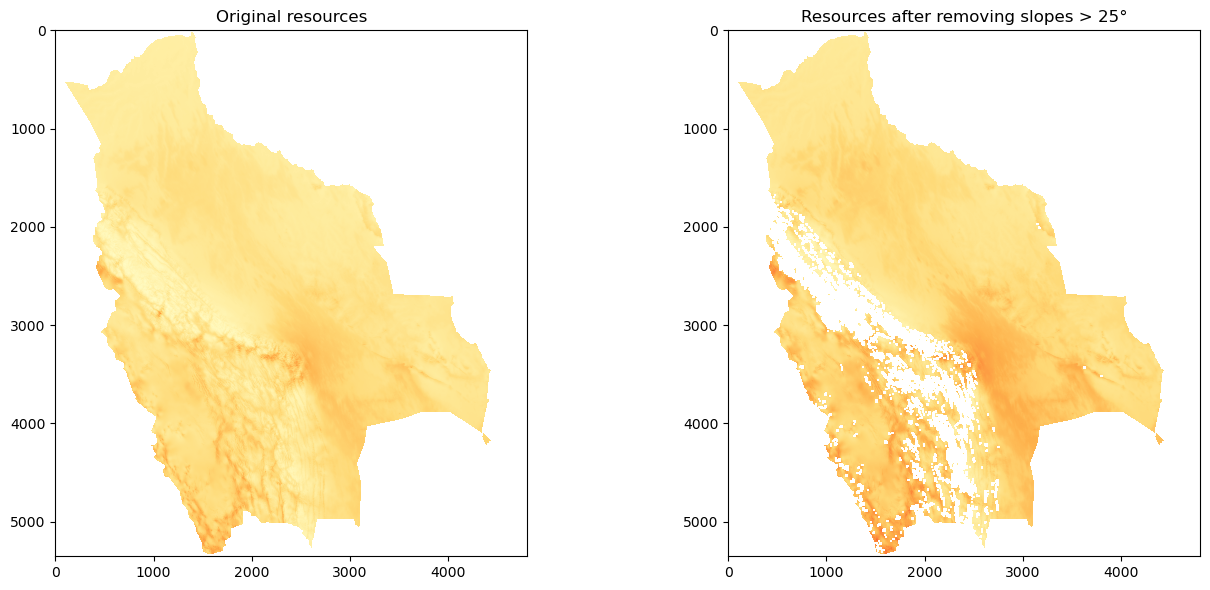

In [42]:
from rasterio.warp import reproject, Resampling

with rasterio.open(Path_All_resources) as src_res:
    resources = src_res.read(1).astype(float)
    resources[resources == src_res.nodata] = np.nan
    
    with rasterio.open(Path_Slope_map) as src_slope:

        # Create an empty array with the same shape as resources
        slopes_resampled = np.empty_like(resources)
        
        reproject(
            source=rasterio.band(src_slope, 1),
            destination=slopes_resampled,
            src_transform=src_slope.transform,
            src_crs=src_slope.crs,
            dst_transform=src_res.transform,
            dst_crs=src_res.crs,
            resampling=Resampling.nearest
        )


# Mask out high slope areas from resources
slope_threshold = 25
resources_filtered = resources.copy()
resources_filtered[slopes_resampled > slope_threshold] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources, cmap="YlOrRd")
axes[0].set_title("Original resources")

axes[1].imshow(resources_filtered, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes > {slope_threshold}°")

plt.tight_layout()
plt.show()

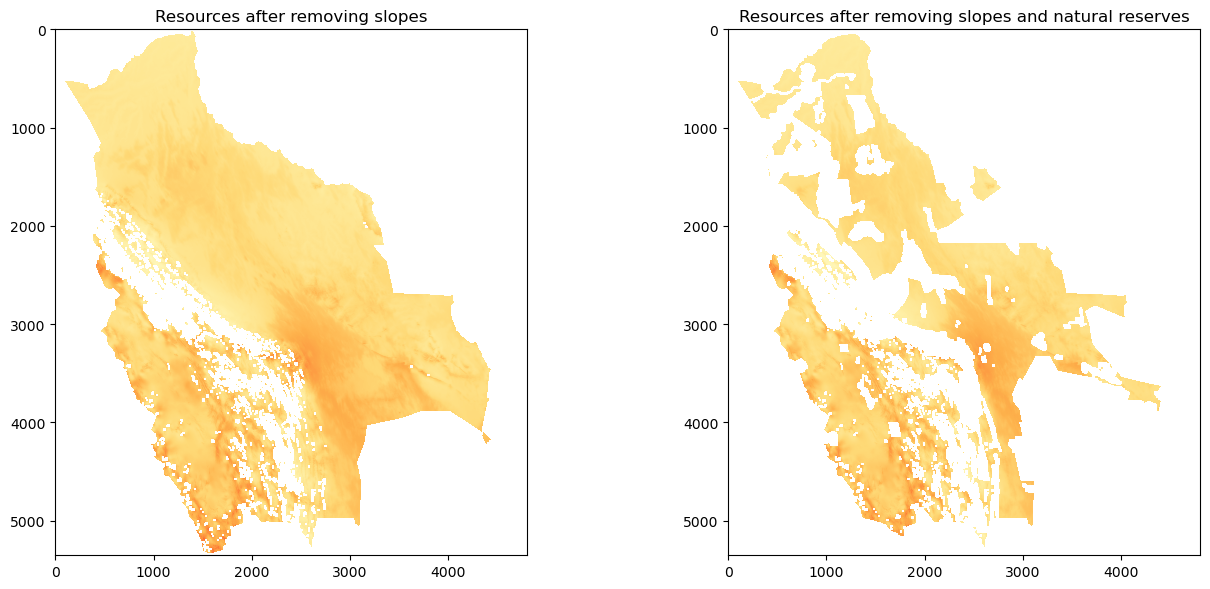

In [43]:
from rasterio.features import geometry_mask

with rasterio.open(Path_All_resources) as src_res:
    # Create a mask from the shapefile (True where polygons are)
    mask = geometry_mask(
        natural_reserves.geometry,
        transform=src_res.transform,
        invert=True,
        out_shape=(src_res.height, src_res.width)
    )

# Remove those regions from resources_filtered
resources_filtered_v2 = resources_filtered.copy()
resources_filtered_v2[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes")

axes[1].imshow(resources_filtered_v2, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves")

plt.tight_layout()
plt.show()

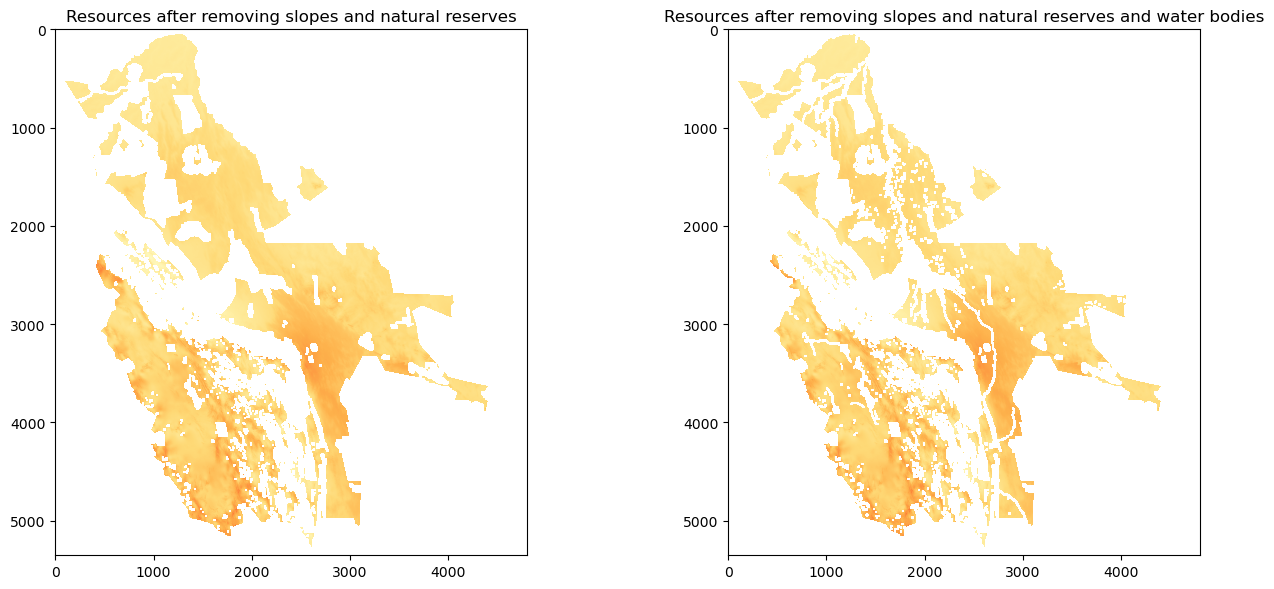

In [44]:
with rasterio.open(Path_All_resources) as src_res:
    # Create a mask from the shapefile (True where polygons are)
    mask = geometry_mask(
        water_bodies.geometry,
        transform=src_res.transform,
        invert=True,
        out_shape=(src_res.height, src_res.width)
    )

# Remove those regions from resources_filtered
resources_filtered_v3 = resources_filtered_v2.copy()
resources_filtered_v3[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered_v2, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes and natural reserves")

axes[1].imshow(resources_filtered_v3, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves and water bodies")

plt.tight_layout()
plt.show()

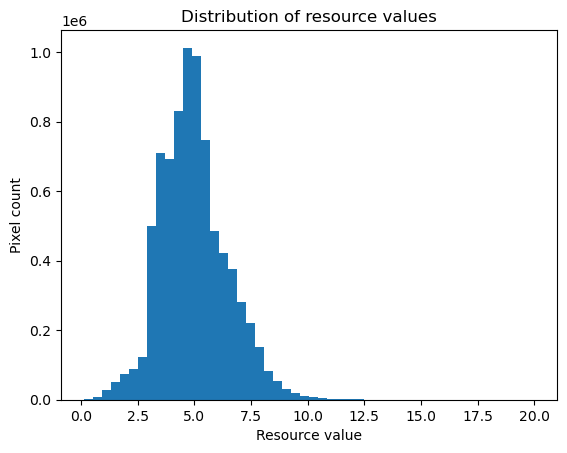

In [45]:
plt.hist(resources_filtered_v3[~np.isnan(resources_filtered_v3)], bins=50)
plt.xlabel("Resource value")
plt.ylabel("Pixel count")
plt.title("Distribution of resource values")
plt.show()

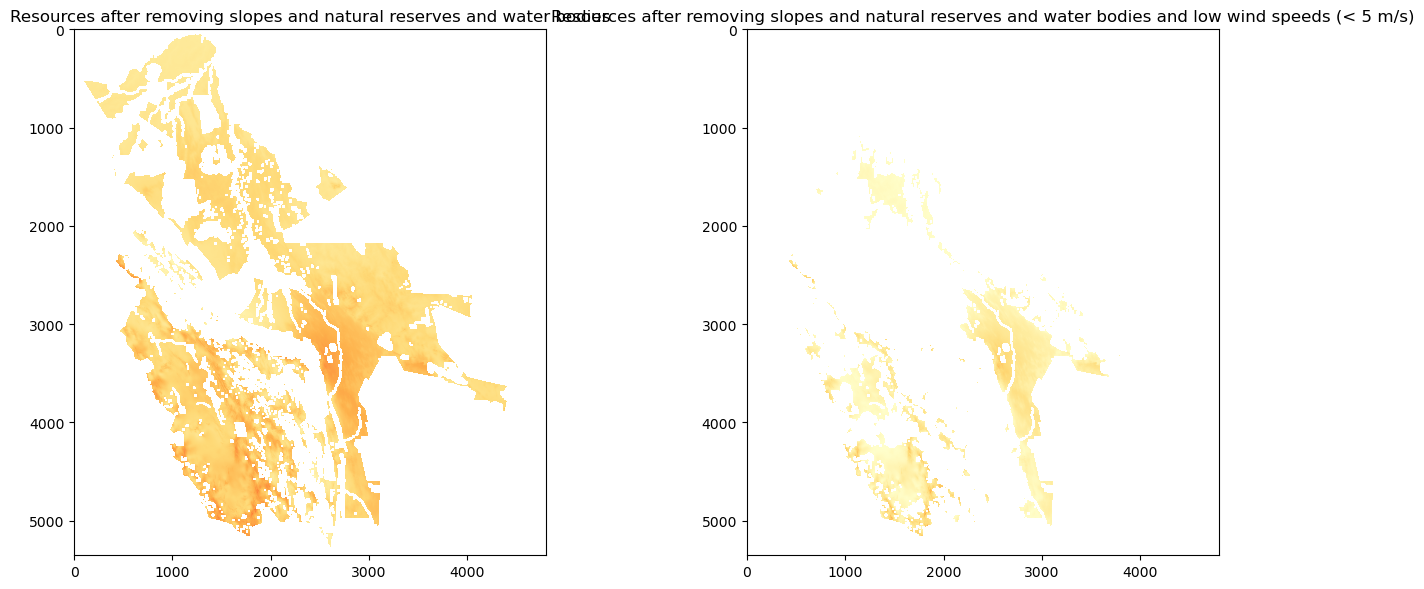

In [46]:
# Keep only high resource areas
threshold = 5  # adjust to your resource units

resources_filtered_v4 = resources_filtered_v3.copy()
resources_filtered_v4[resources_filtered_v4 < threshold] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(resources_filtered_v3, cmap="YlOrRd")
axes[0].set_title("Resources after removing slopes and natural reserves and water bodies")

axes[1].imshow(resources_filtered_v4, cmap="YlOrRd")
axes[1].set_title(f"Resources after removing slopes and natural reserves and water bodies and low wind speeds (< {threshold} m/s)")

plt.tight_layout()
plt.show()

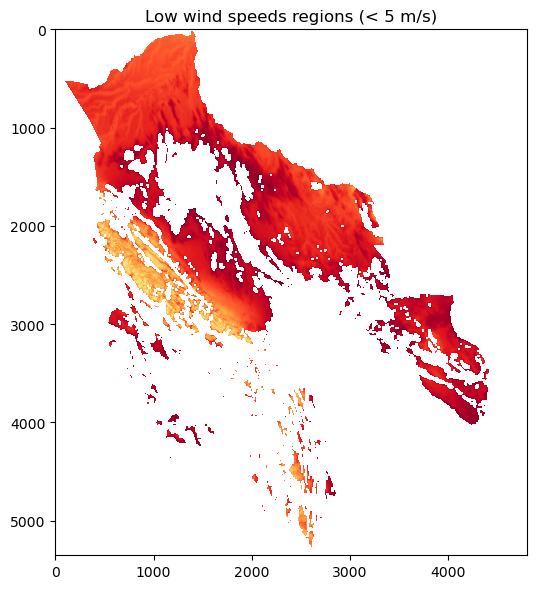

In [54]:
# Keep only high resource areas
threshold = 5  # adjust to your resource units

resources_filtered_v4 = resources.copy()
resources_filtered_v4[resources_filtered_v4 > threshold] = np.nan

fig, axes = plt.subplots(figsize=(8, 6))

axes.imshow(resources_filtered_v4, cmap="YlOrRd")
axes.set_title(f"Low wind speeds regions (< {threshold} m/s)")

plt.tight_layout()
plt.show()

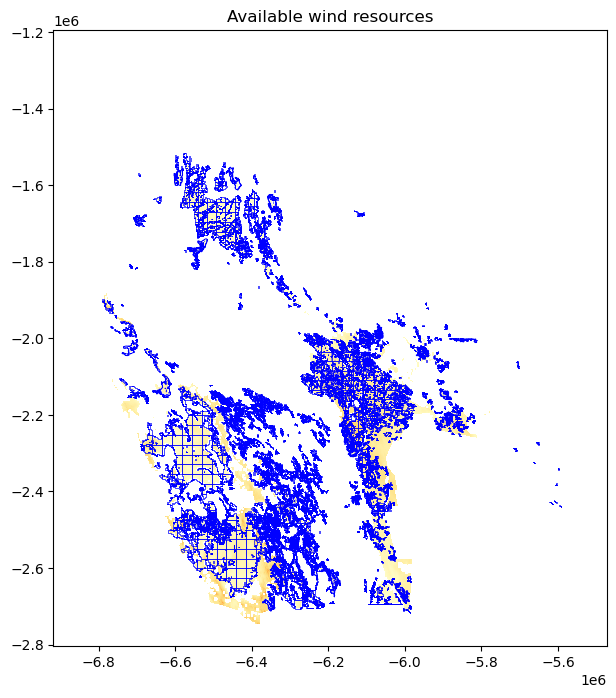

In [48]:
with rasterio.open(Path_All_resources) as src_res:
    msr_shapefile = gpd.read_file(Path_MSR_map).to_crs(src_res.crs)

fig, ax = plt.subplots(figsize=(10, 8))
show(resources_filtered_v4, transform=src_res.transform, ax=ax, cmap="YlOrRd")
msr_shapefile.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=0.5)
ax.set_title("Available wind resources")
plt.show()